<a href="https://colab.research.google.com/github/RuiRodrigues-lab/DataScienceFE/blob/Locker/CP4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='Exerc8')
df.head()

Saving CP4_8.xlsx to CP4_8.xlsx


,Idade,Consumo
0,10,14.3
1,10,14.2
2,11,13.9
3,12,13.7
4,13,12.9


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Idade    26 non-null     int64  
 1   Consumo  26 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 548.0 bytes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


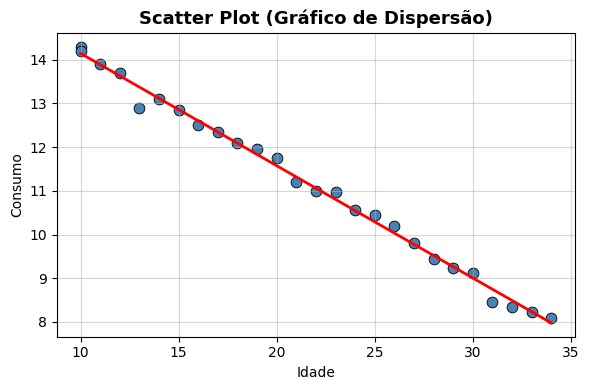

Coeficiente angular (b1): -0.26
Intercepto (b0): 16.71
Correlação de Pearson:  -0.997104
Correlação de Spearman: -0.999145

Equação: Consumo = 16.71 + -0.26 × Idade


In [4]:
# 🔹 Gráfico de dispersão (equivalente a plot())
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x="Idade", y="Consumo",
    data=df, color="steelblue", s=60, edgecolor="black"
)

# 🔹 Regressão linear (equivalente a lm() + abline())
X = df[["Idade"]]
y = df["Consumo"]

model = LinearRegression()
model.fit(X, y)

# Gerar valores previstos
x_vals = np.linspace(df["Idade"].min(), df["Idade"].max(), 100)
y_vals = model.predict(x_vals.reshape(-1, 1))

plt.plot(x_vals, y_vals, color="red", linewidth=2)

# 🔹 Melhorar o gráfico
plt.title("Scatter Plot (Gráfico de Dispersão)", fontsize=13, weight="bold")
plt.xlabel("Idade")
plt.ylabel("Consumo")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

# 🔹 Coeficientes (opcional)
print(f"Coeficiente angular (b1): {model.coef_[0]:.2f}")
print(f"Intercepto (b0): {model.intercept_:.2f}")

# 🔹 Correlação de Pearson (linear)
cor_pearson = df["Consumo"].corr(df["Idade"], method="pearson")

# 🔹 Correlação de Spearman (por postos)
cor_spearman = df["Consumo"].corr(df["Idade"], method="spearman")

print(f"Correlação de Pearson:  {cor_pearson:.6f}")
print(f"Correlação de Spearman: {cor_spearman:.6f}")

print(f"\nEquação: Consumo = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Idade")